```text

* 웹서칭을 위한 query 재작성
* 웹서치의 결과를 활용해서 답변 generate
┌──────────┐     ┌────────────┐     ┌────────────┐
│ Question │────▶│  Retrieve  │────▶│   Grade    │
└──────────┘     │   (Node)   │     │   (Node)   │
                 └────────────┘     └──────┬─────┘
                                           ▼
                                  ◇ Any doc irrelevant?
                                     ╱           ╲
                                   No             Yes
                                   │               │
                                   ▼               ▼
                           ┌────────────┐   ┌────────────────┐
                           │  Generate  │   │ Re-write query │
                           │   (Node)   │   │     (Node)     │
                           └──────┬─────┘   └────────┬───────┘
                                  │                  ▼
                                  │          ┌────────────┐
                                  │          │ Web Search │
                                  │          │   (Node)   │
                                  │          └──────┬─────┘
                                  │                 │
                                  ◀─────────────────┘
                                  │
                                  ▼
                           ┌────────────┐
                           │   Answer   │
                           └────────────┘


```

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# DB 접근
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings

embedding_function = OllamaEmbeddings(
    model="bge-m3",
    base_url="http://localhost:11434"
)

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='income_tax_collection',
    persist_directory='../income_tax_collection'   # 로컬에 설정한 경로로 데이터가 남음 (DB의 역할을 한다)
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [3]:
"""
context 가 우리가 구성한 rag 파이프라인에서 벡터 스토어 대상으로 검색을 했었는데
이번부터는 웹검색의 결과 또한 context에 추가되어 들어간다
"""

'\ncontext 가 우리가 구성한 rag 파이프라인에서 벡터 스토어 대상으로 검색을 했었는데\n이번부터는 웹검색의 결과 또한 context에 추가되어 들어간다\n'

In [4]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List   # 수정
    answer: str
    
graph_builder = StateGraph(AgentState)

In [5]:
def retrieve(state: AgentState):
    query = state["query"]  # state 에서 query 를 꺼내온다.
    
    docs = retriever.invoke(query)  # 검색한 문서

    return {'context': docs} 

In [6]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='exaone3.5:7.8b',
    # temperature=0,
    # reasoning=False,  # 긴 내부 추론을 끔
    # num_ctx=8192,  # 입력과 출력을 합친 컨텍스트 한도를 늘림
)

In [7]:
from langsmith import Client

client = Client()

In [8]:
from langchain_core.output_parsers import StrOutputParser

generate_prompt = client.pull_prompt(
    "rlm/rag-prompt",
    dangerously_pull_public_prompt=True,
    )

def generate(state:AgentState):
    context = state['context']
    query = state['query']

    rag_chain = generate_prompt | llm | StrOutputParser()
    response = rag_chain.invoke({'question': query, 'context': context})  

    # response 를 return
    return {'answer': response}


In [9]:
# Langsmith의 프롬프트 활용 - 노션 참고
from typing import Literal

doc_relevance_prompt = client.pull_prompt(
    "langchain-ai/rag-document-relevance",
    dangerously_pull_public_prompt=True,
)

def check_doc_relevance(state:AgentState) -> Literal["relevant", "irrelevant"]:
    context = state['context']
    query = state['query']

    print(f'context== {context}')

    doc_relevance_chain = doc_relevance_prompt | llm

    response = doc_relevance_chain.invoke({'question': query, 'documents': context})  
    print(f'response== {response}')
  
    if response['Score'] == 1:
        return 'relevant'
    
    return 'irrelevant'   

In [10]:
# 프롬프트 작성 (PromptTemplate 활용)

from langchain_core.prompts import PromptTemplate

rewrite_prompt = PromptTemplate.from_template("""
    사용자의 질문을 보고, 웹 검색에 용이하게 사용자의 질문을 수정해주세요.
    질문: {query}
    """
)

def rewrite(state:AgentState):
    query = state['query']

    rewrite_chain = rewrite_prompt | llm | StrOutputParser()   # 체이닝
    response = rewrite_chain.invoke({'query': query})  

    print(f'rewrite question == {response}')
    return {'query': response}

In [11]:
## 신규 노드 추가 (웹검색 노드)

In [12]:
"""
레거시 코드
"""
# from langchain_community.tools import TavilySearchResults

# tavily_search_tool = TavilySearchResults(
#     max_results=3,
#     search_depth="advanced",
#     include_answer=True,
#     include_raw_content=True,
#     include_images=True,
# )

'\n레거시 코드\n'

In [13]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=3,
    search_depth = "advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

# 노드 생성
def web_search(state: AgentState):
    query=state['query']
    results = tavily_search_tool.invoke(query)
    print(f'web_search === {results}')
    return {'context':results} # result는 List 형태

- 노드 추가

In [14]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('web_search', web_search)

In [15]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve', 
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelevant': 'rewrite'
    }
)

graph_builder.add_edge('rewrite', 'web_search')
graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

In [16]:
graph = graph_builder.compile()

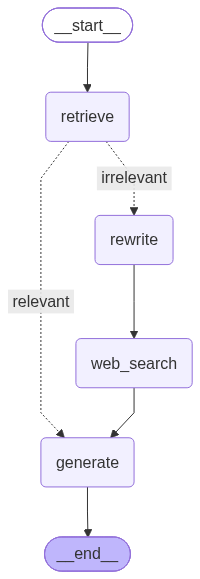

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
# # 작동 확인
# initial_state = {'query': '연봉 5천만원인 거주자의 소득세는 얼마인가요?'}
# graph.invoke(initial_state)

In [19]:
"""
가져온 문서가 relevant 하니까 답변을 바로 생성했음을 볼 수 있음
"""

'\n가져온 문서가 relevant 하니까 답변을 바로 생성했음을 볼 수 있음\n'

In [ ]:
# 에러 확인
error_initial_state = {'query': '역삼역 맛집은?'}
graph.invoke(error_initial_state)

context== [Document(id='42215247-444c-4416-82b6-51fe86c53cd4', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='[본조신설 2020. 12. 29.]\n제156조의9(외국인 통합계좌를 통하여 지급받는 국내원천소득에 대한 원천징수 특례) ① 비거주자가 외국인 통합계좌(「자본시장과 금융투자업에 관한 법률」 제122조제2항제11호목에 따른 외국 금융투자업자 기타 외국 투자자와 주식 매매거래를 일괄하여 주문·결제하기 위하여 자기 명의로 개설한 계좌를 말한다. 이하 같다)를 통하여 제119조제1호 국내원천소득을 지급받는 경우 해당 국내원천소득을 외국인 통합계좌를 통하여 지급받는 자는 외국인 통합계좌의 입원인에게 그 소득금액을 지급할 때 제156조제1항 각 호에 따른 금액을 소득세로 원천징수하여야 한다.\n② 제1항에 따라 소득을 지급받는 비거주자는 조세조약상 비과세·면제 및 제한세율을 적용받으려는 경우에는 납세지 관할 세무서장에게 경정을 청구할 수 있다.\n③ 비거주자가 제2항에 따라 경정을 청구하는 경우 경정청구의 기한 및 방법·절차 등에 관하여는 제156조의2의 통합계좌 세칙과 규칙 및 제156조의6제4항부터 제6항까지를 준용한다. ④ 3항 및 제156조의2의3항 본문 중 “실질귀속자가”와 “실질귀속자 또는 소득지급자가”와 제156조의6제4항 본문 중 “실질귀속자 또는 원천소득귀속자”는 각각 “계좌주자”로 본다.\n[본조신설 2023. 12. 31.]\n제157조(원천징수의 승계) ① 법인이 해산한 경우에 원천징수를 하여야 할 소득세를 징수하지 아니하였거나 징수한 소득세를 납부하지 아니하고 잔여재산을 분배하였을 때에는 청산인은 그 분배율을 한도로 하여 분배를 받은 자와 연\n법제처 120 국가법령정보센터\n대하여 납세의무를 진다.\n  ② 법인이 합병한 경우에 합병 후 존속하는 법인이나 합병으로 설립된 법인은, 합병으로 소멸된 

{'query': '다음과 같이 수정하여 웹 검색에 더 용이하게 만드실 수 있습니다:\n\n**"역삼역 지역의 최고 맛집 추천 (한식, 양식, 중식 등 카테고리 포함)"**\n\n이 수정된 질문은 구체적인 카테고리를 포함하여 사용자의 관심사를 명확히 하고, 검색 엔진이 더 정확한 결과를 제공하도록 돕습니다. 필요에 따라 원하는 음식 종류를 추가하거나 제거할 수 있습니다.',
 'context': {'query': '다음과 같이 수정하여 웹 검색에 더 용이하게 만드실 수 있습니다:\n\n**역삼역 지역의 최고 맛집 추천 (한식, 양식, 중식 등 카테고리 포함)**\n\n이 수정된 질문은 구체적인 카테고리를 포함하여 사용자의 관심사를 명확히 하고, 검색 엔진이 더 정확한 결과를 제공하도록 돕습니다. 필요에 따라 원하는 음식 종류를 추가하거나 제거할 수 있습니다.',
  'follow_up_questions': None,
  'answer': 'The sources recommend several top eateries in the 역삼역 area, including Korean, Western, and Chinese cuisines. For Korean food, popular spots are 이도곰탕 for 곰탕, 서울집 for 만두전골, and 지아니스나폴리 for 화덕피자 & 파스타. For Western food, 지아니스나폴리 is highly recommended for Italian cuisine, and 갈비다움 for 갈비탕. For Chinese food, 명정루 is praised for 중화국밥, and 웨이웨이 for 우삼겹 탄탄면. Other notable mentions include 심가네 칼국수 for 칼국수, 청수횟집 for 생선구이, and 평가옥 for 소고기 온반.',
  'images': ['https://mblogthumb-phinf.pstatic.net/MjAyNDExMTVfMjkw/MDAxNzMxNjQwODI1ODY0

In [ ]:
"""
가져온 문서가 relevant 하지 않기 때문에 "rewrite question == 다음과 같이 수정하여 웹 검색에 더 용이하게 만드실 수 있습니다" 와 같이 질문을 다시 작성한다.
web_search === {'query': '다음과 같이 수정하여 웹 검색에 더 용이하게 만드실 수 있습니다 ... } 
"""

'\n가져온 문서가 relevant 하지 않기 때문에 "rewrite question == 다음과 같이 수정하여 웹 검색에 더 용이하게 만드실 수 있습니다" 와 같이 질문을 다시 작성한다.\nweb_search === {\'query\': \'다음과 같이 수정하여 웹 검색에 더 용이하게 만드실 수 있습니다:\n\n**역삼역 지역의 최고 맛집 추천 (한식, 양식, 중식 등 카테고리 포함)**\n\n이 수정된 질문은 구체적인 카테고리를 포함하여 사용자의 관심사를 명확히 하고, 검색 엔진이 더 정확한 결과를 제공하도록 돕습니다. 필요에 따라 원하는 음식 종류를 추가하거나 제거할 수 있습니다.\', \'follow_up_questions\': None, \'answer\': \'The sources recommend several top eateries in the 역삼역 area, including Korean, Western, and Chinese cuisines. For Korean food, popular spots are 이도곰탕 for 곰탕, 서울집 for 만두전골, and 지아니스나폴리 for 화덕피자 & 파스타. For Western food, 지아니스나폴리 is highly recommended for Italian cuisine, and 갈비다움 for 갈비탕. For Chinese food, 명정루 is praised for 중화국밥, and 웨이웨이 for 우삼겹 탄탄면. Other notable mentions include 심가네 칼국수 for 칼국수, 청수횟집 for 생선구이, and 평가옥 for 소고기 온반.\', \'images\': [\'https://mblogthumb-phinf.pstatic.net/MjAyNDExMTVfMjkw/MDAxNzMxNjQwODI1ODY0.yXGDqgzS2imRT0uSK-ECSBwOnAAGOPPddAzQIkXurhAg.o8nG-oHH-EObhJE7pCSKcl6VJElU_EfsT-lOaM0s4MMg.JPE

In [ ]:
"""
* rewrite 노드가 필요한가 (질문을 얼마나 잘 수정하는지) -> 필요 없을 수 있음

* openai 에서 자체적으로 업데이트 -> 비슷한 질문이 들어오면 캐시한 답변을 바로 주는 식으로 openai api가 업데이트 됨 -> 비슷한 질문을 하면 답변 속도가 더 빨라진다.
* 서비스 관점에서 필요한 부분인지에 대해서 생각을 해봐야 함 (LLM을 한번 더 호출하게 되면 비용이 더 들기 때문에)
"""